In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df = df.drop('customerID' , axis = 1)

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors = 'coerce')
df = df.dropna()

In [9]:
df = pd.get_dummies(df , drop_first='True')

In [11]:
X = df.drop('Churn_Yes' , axis = 1)
y = df['Churn_Yes']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_test,X_train , Y_test , Y_train = train_test_split(X,y,test_size=0.2 , random_state=42)

In [14]:
from imblearn.over_sampling import SMOTE

In [15]:
smote = SMOTE()

In [16]:
X_train , Y_train = smote.fit_resample(X_train , Y_train)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [18]:
models = {
    "Logistic":LogisticRegression(max_iter=1000),
    "rf":RandomForestClassifier(),
    "XGB":XGBClassifier(use_label_encoder=False , eval_metric='logloss')
}

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score

results = {}

for name , model in models.items():
  model.fit(X_train , Y_train)
  preds = model.predict(X_test)
  prob = model.predict_proba(X_test)[: , 1]

  results[name] = {
      "accuracy":accuracy_score(Y_test , preds),
      "rocauc":roc_auc_score(Y_test , prob)
  }

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:01:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [20]:
results

{'Logistic': {'accuracy': 0.7740444444444444,
  'rocauc': np.float64(0.820013037809648)},
 'rf': {'accuracy': 0.7761777777777777,
  'rocauc': np.float64(0.809316041364678)},
 'XGB': {'accuracy': 0.7569777777777777,
  'rocauc': np.float64(0.7977840582409484)}}

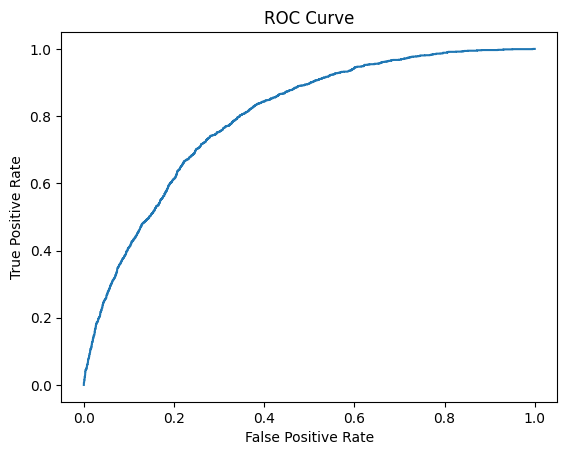

In [22]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(Y_test, prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

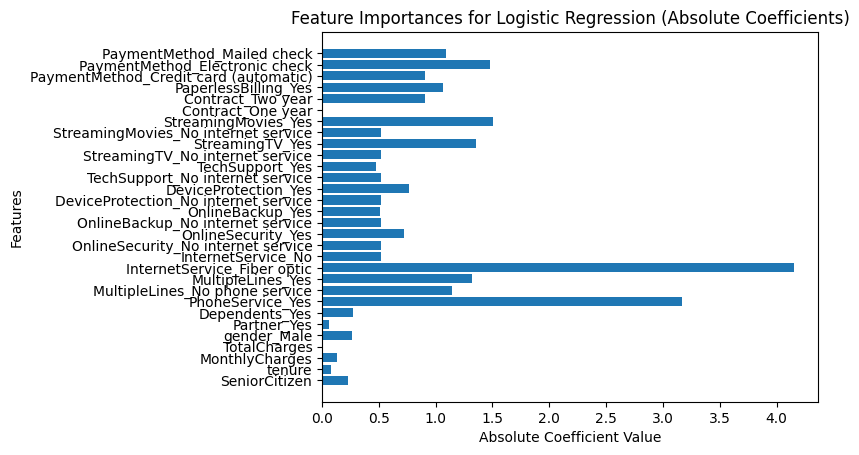

In [25]:
model = models["Logistic"]

# For Logistic Regression, use coefficients as importance
# Take the absolute value as importance is about magnitude of influence
importances = abs(model.coef_[0])
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importances for Logistic Regression (Absolute Coefficients)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Features")
plt.show()

In [31]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))

In [28]:
!pip install streamlit
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("model.pkl", "rb"))

st.title("Customer Churn Prediction")

tenure = st.slider("Tenure", 0, 72)
monthly = st.number_input("Monthly Charges")

if st.button("Predict"):
    input_data = np.array([[tenure, monthly]])
    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("Customer will churn")
    else:
        st.success("Customer will stay")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 117.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 98.3 kB/s eta 0:00:00


2026-04-02 12:20:54.171 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 12:20:54.336 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-02 12:20:54.337 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 12:20:54.338 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 12:20:54.339 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 12:20:54.339 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 12:20:54.339 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 12:20:54.340 Thread 'MainThread': mi

In [32]:
from google.colab import files


files.download("columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>